ERROR:root:Algorithm vtkEvenlySpacedStreamlines2D (0x14caa1c90) returned failure for request: vtkInformation (0x14eb73cc0)
  Debug: Off
  Modified Time: 172539
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0
2026-06-16 10:58:45.551 ( 743.014s) [          3738EE]       vtkExecutive.cxx:741    ERR| vtkCompositeDataPipeline (0x14eb732c0): Algorithm vtkEvenlySpacedStreamlines2D (0x14caa1c90) returned failure for request: vtkInformation (0x14eb73cc0)
  Debug: Off
  Modified Time: 172539
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0




number_time_points: 12
Using time_index: 11
time value: 0.1
UnstructuredGrid (0x148c246a0)
  N Cells:    23503
  N Points:   13876
  X Bounds:   -4.955e-16, 1.000e+00
  Y Bounds:   -3.660e-01, 1.366e+00
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   27
n_points: 13876
n_cells : 23503
bounds  : BoundsTuple(x_min = -4.954803928258755e-16,
            x_max =  1.0,
            y_min = -0.3660254180431366,
            y_max =  1.366025447845459,
            z_min =  0.0,
            z_max =  0.0)
point_data: ['U_tilde', 'p_l_perturbation', 'U_tilde_old', 'p_l_perturbation_old', 'U_bar', 'U_tot', 'F_tot', 'J_tot', 'C_tot', 'E_tot', 'Sigma_skel', 'sigma_skel', 'Phis', 'Phif', 'pl_affine', 'pl_bar', 'pl_tot', 'K_l_ref', 'k_l_intr', 'q_l', 'Q_l']
cell_data : ['U_bar', 'S_area', 'lambda_p_l_perturbation_zero_mean', 'U_bar_old', 'S_area_old', 'lambda_p_l_perturbation_zero_mean_old']
Using pressure field: pl_tot
pl_tot in point_data
  shape: (13876,)
  min  : -0.08681217
  max  : 0.08688186
Usi

/var/folders/b4/8fl3sj757mn34x4m3vh5_1nh0000gp/T/ipykernel_4474/3179714191.py:318: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show(auto_close=False)


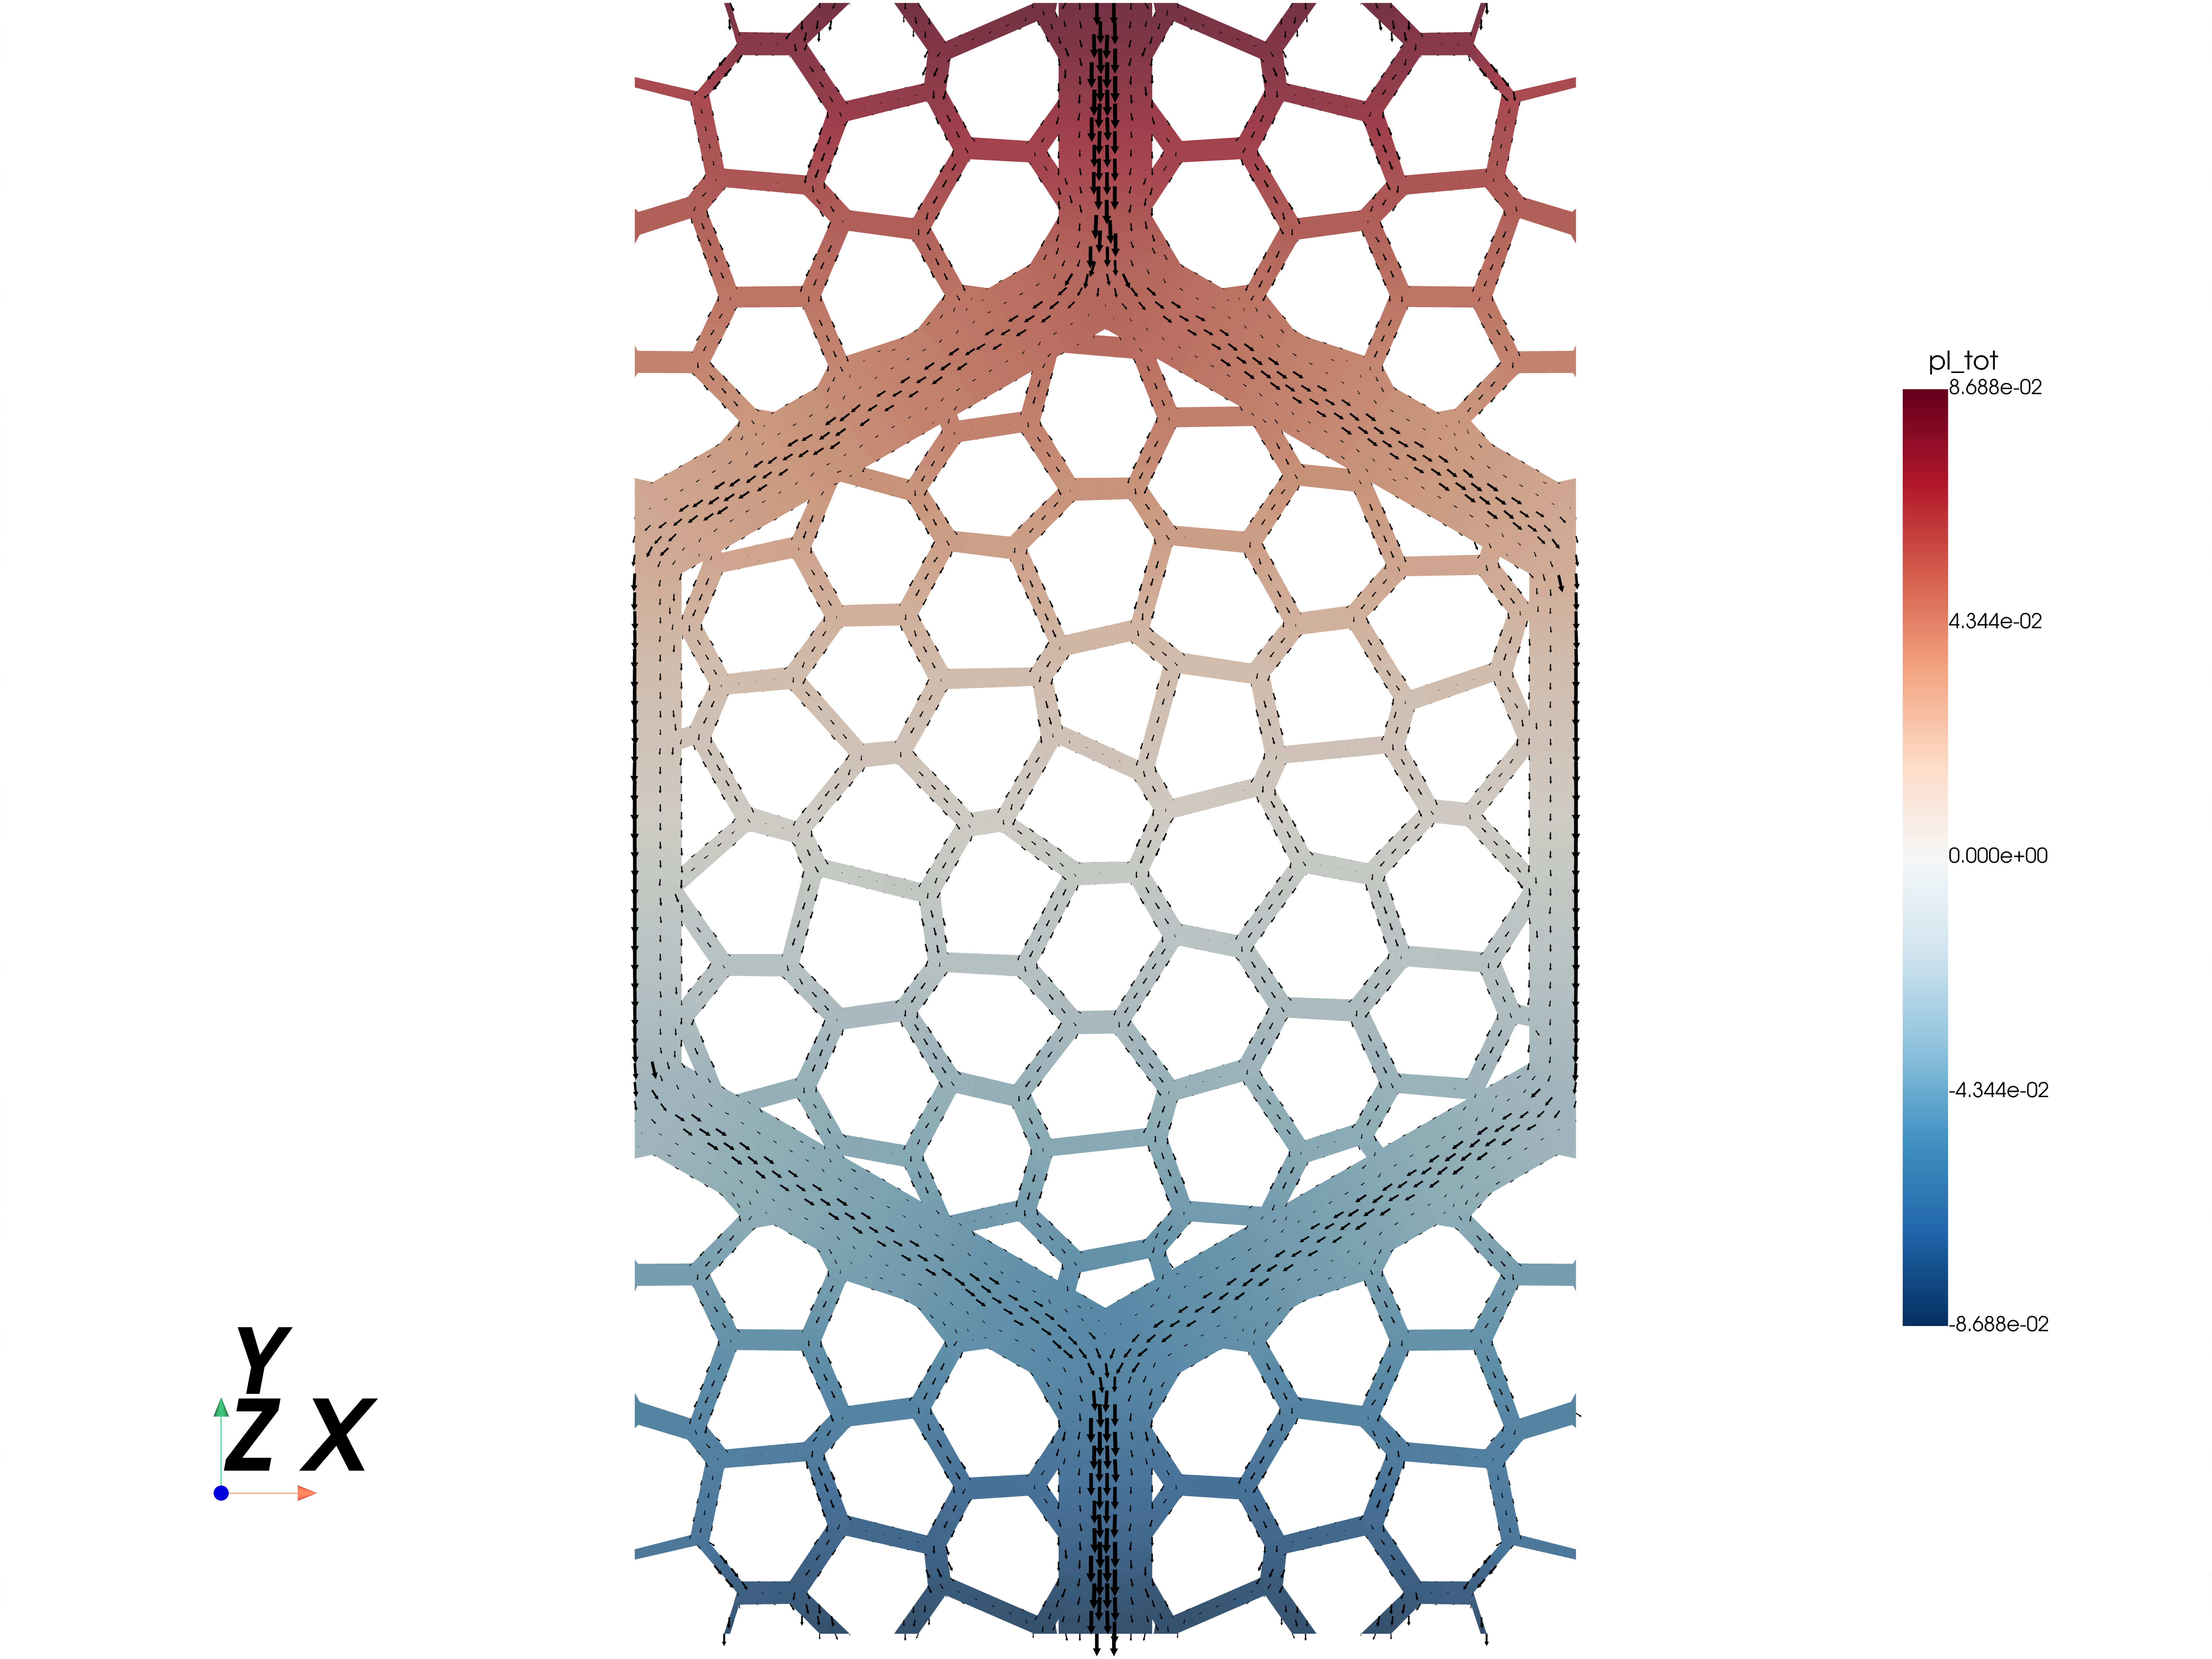

Saved: /Users/xiao/PhD/Project_Acinar_Perfusion/results/pyvista/run_with_airway_flux_pl_tot_t-1_streamlines_highres.png


: 

In [ ]:
from pathlib import Path
import argparse
import numpy as np
import pyvista as pv


def single_mesh(data):
    if isinstance(data, pv.MultiBlock):
        blocks = []
        for block in data:
            if block is None:
                continue
            block = single_mesh(block)
            if isinstance(block, pv.MultiBlock):
                for subblock in block:
                    if subblock is not None:
                        blocks.append(subblock)
            else:
                blocks.append(block)

        if len(blocks) == 0:
            raise RuntimeError("No mesh block found in XDMF file.")

        if len(blocks) == 1:
            return blocks[0]

        return pv.MultiBlock(blocks).combine()

    return data


def read_xdmf(filename, time_index=-1):
    reader = pv.get_reader(str(filename))

    if hasattr(reader, "number_time_points"):
        try:
            n_time = reader.number_time_points
            print("number_time_points:", n_time)

            if n_time is not None and n_time > 0:
                if time_index is None:
                    time_index = n_time - 1
                elif time_index < 0:
                    time_index = n_time + time_index

                print("Using time_index:", time_index)

                if hasattr(reader, "time_values"):
                    try:
                        print("time value:", reader.time_values[time_index])
                    except Exception:
                        pass

                reader.set_active_time_point(time_index)
        except Exception as error:
            print("Could not set time point:")
            print(error)

    data = reader.read()
    mesh = single_mesh(data)

    points = np.asarray(mesh.points)

    if points.shape[1] == 3:
        z_span = float(np.max(points[:, 2]) - np.min(points[:, 2]))
        if z_span < 1e-12:
            mesh.points[:, 2] = 0.0

    return mesh


def print_info(mesh):
    print(mesh)
    print("n_points:", mesh.n_points)
    print("n_cells :", mesh.n_cells)
    print("bounds  :", mesh.bounds)
    print("point_data:", list(mesh.point_data.keys()))
    print("cell_data :", list(mesh.cell_data.keys()))


def print_array_stats(mesh, name):
    if name is None:
        return

    if name in mesh.point_data:
        values = np.asarray(mesh.point_data[name])
        location = "point_data"
    elif name in mesh.cell_data:
        values = np.asarray(mesh.cell_data[name])
        location = "cell_data"
    else:
        print(f"{name}: not found")
        return

    print(f"{name} in {location}")
    print("  shape:", values.shape)
    print("  min  :", np.nanmin(values, axis=0))
    print("  max  :", np.nanmax(values, axis=0))


def find_array(mesh, requested, candidates):
    keys = list(mesh.point_data.keys()) + list(mesh.cell_data.keys())

    if requested not in [None, "auto"]:
        if requested in keys:
            return requested
        raise RuntimeError(f"Array '{requested}' not found. Available arrays: {keys}")

    for name in candidates:
        if name in keys:
            return name

    return None


def to_point_data(mesh):
    if len(mesh.cell_data.keys()) > 0:
        return mesh.cell_data_to_point_data(pass_cell_data=True)
    return mesh


def ensure_scalar_as_point_data(mesh, scalar_name):
    if scalar_name is None:
        return mesh, None

    if scalar_name in mesh.point_data:
        return mesh, scalar_name

    if scalar_name in mesh.cell_data:
        mesh = mesh.cell_data_to_point_data(pass_cell_data=True)
        return mesh, scalar_name

    keys = list(mesh.point_data.keys()) + list(mesh.cell_data.keys())
    raise RuntimeError(f"Scalar '{scalar_name}' not found. Available arrays: {keys}")


def ensure_vector_3d(mesh, vector_name):
    mesh = to_point_data(mesh)

    if vector_name not in mesh.point_data:
        raise RuntimeError(f"Vector '{vector_name}' is not available as point data.")

    values = np.asarray(mesh.point_data[vector_name])

    if values.ndim != 2:
        raise RuntimeError(f"Array '{vector_name}' is not a vector field.")

    if values.shape[1] == 2:
        new_name = vector_name + "_3d"
        mesh.point_data[new_name] = np.column_stack(
            [values[:, 0], values[:, 1], np.zeros(values.shape[0])]
        )
        vector_name = new_name
    elif values.shape[1] != 3:
        raise RuntimeError(f"Array '{vector_name}' has shape {values.shape}, not a 2D/3D vector field.")

    mesh.set_active_vectors(vector_name)

    return mesh, vector_name


def make_vector_from_pressure(mesh, pressure_name):
    mesh = to_point_data(mesh)

    if pressure_name not in mesh.point_data:
        raise RuntimeError(f"Pressure '{pressure_name}' is not available as point data.")

    mesh = mesh.compute_derivative(scalars=pressure_name, gradient="grad_p")
    grad_p = np.asarray(mesh.point_data["grad_p"])

    if grad_p.ndim != 2:
        raise RuntimeError("Computed pressure gradient is not a vector field.")

    if grad_p.shape[1] == 2:
        mesh.point_data["minus_grad_p"] = np.column_stack(
            [-grad_p[:, 0], -grad_p[:, 1], np.zeros(grad_p.shape[0])]
        )
    elif grad_p.shape[1] == 3:
        mesh.point_data["minus_grad_p"] = -grad_p
    else:
        raise RuntimeError(f"Computed pressure gradient has unexpected shape {grad_p.shape}.")

    mesh.set_active_vectors("minus_grad_p")

    return mesh, "minus_grad_p"


def plot_pressure_streamlines(
    mesh,
    pressure_name=None,
    vector_name=None,
    savepath=None,
    show_edges=False,
    separating_distance=0.025,
    show_bounds=False,
    show_arrows_if_streamlines_fail=True,
):
    plotter = pv.Plotter(
        window_size=(2400, 1800),
        off_screen=True,
    )
    plotter.image_scale = 3
    plotter.set_background("white")

    try:
        plotter.enable_anti_aliasing("ssaa")
    except Exception:
        pass

    scalar_bar_args = {
        "title": pressure_name if pressure_name is not None else "",
        "vertical": True,
        "position_x": 0.86,
        "position_y": 0.20,
        "width": 0.055,
        "height": 0.58,
        "title_font_size": 28,
        "label_font_size": 22,
        "fmt": "%.3e",
    }

    if pressure_name is not None:
        values = np.asarray(mesh.point_data[pressure_name])
        vmin = float(np.nanmin(values))
        vmax = float(np.nanmax(values))

        print(f"{pressure_name} range:", vmin, vmax)

        if np.isclose(vmin, vmax):
            eps = 1e-12 if abs(vmin) < 1.0 else 1e-6 * abs(vmin)
            vmin -= eps
            vmax += eps

        absmax = max(abs(vmin), abs(vmax))
        clim = [-absmax, absmax] if absmax > 0 else [vmin, vmax]

        plotter.add_mesh(
            mesh,
            scalars=pressure_name,
            cmap="RdBu_r",
            show_edges=show_edges,
            clim=clim,
            opacity=0.8,
            scalar_bar_args=scalar_bar_args,
        )
    else:
        plotter.add_mesh(
            mesh,
            color="white",
            show_edges=True,
            opacity=0.8,
        )

    streamline_ok = False

    if vector_name is not None:
        try:
            streams = mesh.streamlines_evenly_spaced_2D(
                vectors=vector_name,
                separating_distance=separating_distance,
                separating_distance_ratio=0.2,
                interpolator_type="point",
                compute_vorticity=False,
            )

            if streams.n_points > 0:
                bounds = mesh.bounds
                length = max(bounds[1] - bounds[0], bounds[3] - bounds[2])
                radius = 0.0025 * length
                plotter.add_mesh(streams.tube(radius=radius), color="black")
                streamline_ok = True
                print("Streamlines generated:", streams.n_points)
            else:
                print("No streamlines were generated.")

        except Exception as error:
            print("Streamline plotting failed:")
            print(error)

        if (not streamline_ok) and show_arrows_if_streamlines_fail:
            arrow = pv.Arrow(
                tip_length=0.35,
                tip_radius=0.18,
                shaft_radius=0.08,
                shaft_resolution=32,
                tip_resolution=32,
            )

            glyph_mesh = mesh.glyph(
                orient=vector_name,
                scale=vector_name,
                factor=0.08,
                tolerance=0.006,
                geom=arrow,
            )

            plotter.add_mesh(glyph_mesh, color="black", opacity=1.0)
            print("Using denser and thicker glyph arrows instead of streamlines.")

    plotter.view_xy()
    plotter.enable_parallel_projection()
    plotter.camera.zoom(1.15)
    plotter.add_axes(line_width=3)

    if show_bounds:
        plotter.show_bounds(
            grid="front",
            location="outer",
            font_size=18,
            xtitle="X",
            ytitle="Y",
            ztitle="",
        )

    if savepath is not None:
        savepath = Path(savepath)
        highres_savepath = savepath.with_name(savepath.stem + "_highres.png")
        plotter.show(auto_close=False)
        plotter.screenshot(
            str(highres_savepath),
            window_size=(2400, 1800),
            scale=3,
        )
        plotter.close()
        print("Saved:", highres_savepath)
    else:
        plotter.show()

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--xdmf", default="test_acinar_perfusion_baseline/run_with_airway_flux.xdmf")
    parser.add_argument("--pressure", default="pl_tot")
    parser.add_argument("--vector", default="q_l")
    parser.add_argument("--time-index", type=int, default=-1)
    parser.add_argument("--edges", action="store_true")
    parser.add_argument("--separating-distance", type=float, default=0.025)

    args, unknown = parser.parse_known_args()

    try:
        script_dir = Path(__file__).resolve().parent
    except NameError:
        script_dir = Path.cwd().resolve()

    if script_dir.name == "Project_Acinar_Perfusion":
        project_dir = script_dir
        script_dir = project_dir / "scripts"
    elif script_dir.name == "scripts":
        project_dir = script_dir.parent
    else:
        project_dir = script_dir

    xdmf_file = Path(args.xdmf)

    if not xdmf_file.is_absolute():
        candidates = [
            script_dir / xdmf_file,
            project_dir / xdmf_file,
            project_dir / "scripts" / xdmf_file,
            Path.cwd().resolve() / xdmf_file,
        ]

        for candidate in candidates:
            if candidate.exists():
                xdmf_file = candidate.resolve()
                break
        else:
            print("Tried these paths:")
            for candidate in candidates:
                print("  ", candidate)
            raise FileNotFoundError(xdmf_file)

    if not xdmf_file.exists():
        raise FileNotFoundError(xdmf_file)

    out_dir = project_dir / "results" / "pyvista"
    out_dir.mkdir(parents=True, exist_ok=True)

    mesh = read_xdmf(xdmf_file, time_index=args.time_index)
    print_info(mesh)

    pressure_name = find_array(
        mesh,
        args.pressure,
        ["pl_tot", "p_l_tot", "p_l_perturbation", "pl_affine", "pl_bar", "p_f", "pressure", "p"],
    )

    vector_name = find_array(
        mesh,
        args.vector,
        ["q_l", "Q_l", "flux", "velocity", "v"],
    )

    if pressure_name is None:
        print("No pressure field found. Only mesh will be plotted.")
    else:
        mesh, pressure_name = ensure_scalar_as_point_data(mesh, pressure_name)
        print("Using pressure field:", pressure_name)
        print_array_stats(mesh, pressure_name)

    if vector_name is not None:
        mesh, vector_name = ensure_vector_3d(mesh, vector_name)
        print("Using vector field:", vector_name)
        print_array_stats(mesh, vector_name)
    elif pressure_name is not None:
        mesh, vector_name = make_vector_from_pressure(mesh, pressure_name)
        print("No vector field found. Using -grad(pressure) for visual streamlines.")
        print_array_stats(mesh, vector_name)
    else:
        vector_name = None

    savepath = out_dir / f"{xdmf_file.stem}_{pressure_name}_t{args.time_index}_streamlines.png"

    plot_pressure_streamlines(
        mesh,
        pressure_name=pressure_name,
        vector_name=vector_name,
        savepath=savepath,
        show_edges=args.edges,
        separating_distance=args.separating_distance,
        show_bounds=False,
        show_arrows_if_streamlines_fail=True,
    )

if __name__ == "__main__":
    main()